## Preprocessing

In [1]:
# Importing the dataset
import pandas as pd

df = pd.read_csv("../data/working.csv")

In [27]:
# checking for missing values
print(df.isnull().values.any())
print(df.isnull().sum().sum())

False
0


In [2]:
# selcting only needed features from the dataset
selected_features = [
    "URLLength",
    "IsDomainIP",
    "TLD",
    "NoOfDegitsInURL",
    "NoOfOtherSpecialCharsInURL",
    "IsHTTPS",
    "DomainLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "label"
]

df = df[selected_features]

In [3]:
# seperate the solution (if phishing or legitimate url) from the rest of the data
X = df.drop("label", axis=1)
y = df["label"]

In [4]:
print(df.columns)
print(X.columns)
print(y.name)

Index(['URLLength', 'IsDomainIP', 'TLD', 'NoOfDegitsInURL',
       'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainLength',
       'NoOfSubDomain', 'HasObfuscation', 'label'],
      dtype='object')
Index(['URLLength', 'IsDomainIP', 'TLD', 'NoOfDegitsInURL',
       'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainLength',
       'NoOfSubDomain', 'HasObfuscation'],
      dtype='object')
label


In [5]:
# Checking how many different tld's there are
df["TLD"].nunique()

695

In [6]:
# looking at the top 10 most prevalant
top_tlds = X["TLD"].value_counts().nlargest(10).index
print(top_tlds.values)
X["TLD"].value_counts()

['com' 'org' 'net' 'app' 'uk' 'co' 'io' 'de' 'ru' 'au']


TLD
com           112554
org            18793
net             7097
app             6508
uk              6395
               ...  
15                 1
nr                 1
parts              1
kitchen            1
associates         1
Name: count, Length: 695, dtype: int64

In [7]:
# replacing every other tld with other to limit the amount of different values to 11:
X["TLD"] = X["TLD"].apply(lambda x: x if x in top_tlds else "other")
X["TLD"].nunique()

11

In [8]:
# creating new features to encode the TLD feature into 1 and 0 values for each common top level domain:
X = pd.get_dummies(X, columns=["TLD"])
print(X.columns)
print(len(X.columns))

Index(['URLLength', 'IsDomainIP', 'NoOfDegitsInURL',
       'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainLength',
       'NoOfSubDomain', 'HasObfuscation', 'TLD_app', 'TLD_au', 'TLD_co',
       'TLD_com', 'TLD_de', 'TLD_io', 'TLD_net', 'TLD_org', 'TLD_other',
       'TLD_ru', 'TLD_uk'],
      dtype='object')
19


## Data split

In [9]:
# splitting data into training and testing sets. X is data and y is for evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(188636, 19) (47159, 19)


In [10]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# training the first model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

In [12]:
import joblib

joblib.dump(model_lr, "../models/linear_model3.pkl")

['../models/linear_model3.pkl']

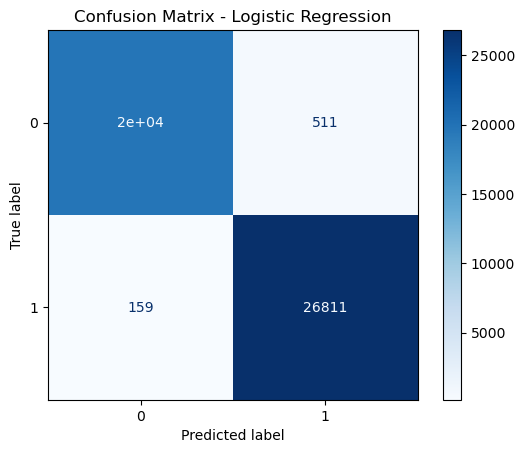

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Experimenting with the Threshold:

#### Threshold Adjustment to Reduce False Negatives

The default decision threshold of logistic regression is **0.5**, meaning a URL is classified as phishing only if the predicted probability is at least 50%.

To reduce false negatives, the threshold was lowered to **0.2**. This makes the model more sensitive to potential phishing URLs.


In [14]:
# training the model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob >= 0.2).astype(int)

In [15]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9836298479611527
[[19473   716]
 [   56 26914]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     20189
           1       0.97      1.00      0.99     26970

    accuracy                           0.98     47159
   macro avg       0.99      0.98      0.98     47159
weighted avg       0.98      0.98      0.98     47159



#### Interpretation:

False negatives dropped significantly (159 → 56).

False positives increased (511 → 716).

Accuracy decreased slightly (98.58% → 98.36%).

#### Threshold Adjustment to Reduce False Negatives

The default decision threshold of logistic regression is **0.5**, meaning a URL is classified as phishing only if the predicted probability is at least 50%.

To reduce false negatives, the threshold was lowered to **0.1**. This makes the model more sensitive to potential phishing URLs.


In [16]:
# training the model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob >= 0.1).astype(int)

In [17]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9807247821200619
[[19307   882]
 [   27 26943]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     20189
           1       0.97      1.00      0.98     26970

    accuracy                           0.98     47159
   macro avg       0.98      0.98      0.98     47159
weighted avg       0.98      0.98      0.98     47159



#### Interpretation:
False negatives decreased further: 159 → 27

False positives increased: 511 → 882

Accuracy dropped slightly: 98.58% → 98.07%

#### Threshold Adjustment to Reduce False Negatives

The default decision threshold of logistic regression is **0.5**, meaning a URL is classified as phishing only if the predicted probability is at least 50%.

To reduce false negatives, the threshold was lowered to **0.05**. This makes the model more sensitive to potential phishing URLs.


In [18]:
# training the model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob >= 0.05).astype(int)

In [19]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9728365741427936
[[18929  1260]
 [   21 26949]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     20189
           1       0.96      1.00      0.98     26970

    accuracy                           0.97     47159
   macro avg       0.98      0.97      0.97     47159
weighted avg       0.97      0.97      0.97     47159



#### Interpretation:

False negatives decreased further: 159 → 21

False positives increased: 511 → 1260

Accuracy dropped slightly: 98.58% → 97.28%

#### Threshold Adjustment to Reduce False Negatives

The default decision threshold of logistic regression is **0.5**, meaning a URL is classified as phishing only if the predicted probability is at least 50%.

To reduce false negatives, the threshold was lowered to **0.01, 0.005, 0.001 and 0.0005**. This makes the model more sensitive to potential phishing URLs.


In [20]:
# training the model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob >= 0.0005).astype(int)

In [21]:
# evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9293242011068937
[[16856  3333]
 [    0 26970]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     20189
           1       0.89      1.00      0.94     26970

    accuracy                           0.93     47159
   macro avg       0.95      0.92      0.93     47159
weighted avg       0.94      0.93      0.93     47159



#### Interpretation:
**0.01**:
False negatives decreased further: 159 → 8

False positives increased: 511 → 1863

Accuracy dropped slightly: 98.58% → 96.03%

**0.005**:
False negatives decreased further: 159 → 4

False positives increased: 511 → 2107

Accuracy dropped slightly: 98.58% → 95.52%

**0.001**:
False negatives decreased further: 159 → 2

False positives increased: 511 → 2989

Accuracy dropped slightly: 98.58% → 93.65%

**0.0005**:
False negatives decreased further: 159 → **0**

False positives increased: 511 → 3333

Accuracy dropped slightly: 98.58% → 92.93%

In [22]:
# cross validation to ensure the result is stable
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_lr, X, y, cv=5)

print(scores.mean())

0.9966793188998917


## conclusion


The number of false negatives can be lowered to zero by adapting the threshold, but this would also lower the accuracy and increase the amount of false positives.
| Threshold | FN    | FP       | Accuracy  |
| --------- | ----- | -------- | --------- |
| 0.5       | 159   | 511      | 98.6%     |
| 0.1       | 27    | 882      | 98.1%     |
| 0.05      | 21    | 1260     | 97.3%     |
| 0.0005    | **0** | **3333** | **92.9%** |


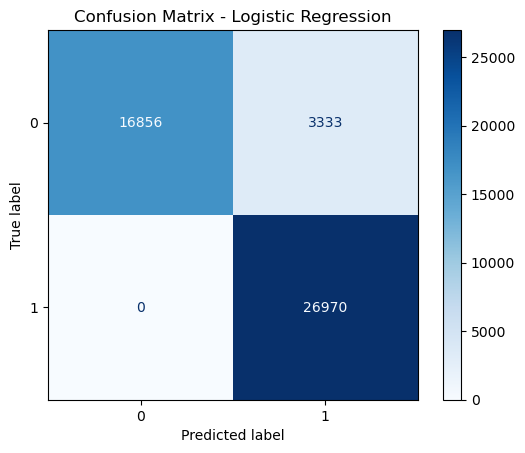

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()